In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Baseline für department jobbert

The tokenizer you are loading from '/content/drive/MyDrive/PDS_Snapaddy/models/jobbertv3_department_FULL_weighted' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Device set to use cpu


=== BASELINE (Conf ≥ 0.9) ===
final_dept_baseline
LowConf/Other             302
Sales                      96
Information Technology     58
Marketing                  44
Consulting                 37
Project Management         37
Business Development       33
Purchasing                 10
Administrative              6
Name: count, dtype: int64
LowConf Reject: 48.5%
✅ Baseline Acc: 0.483 (321 confident Samples)
                        precision    recall  f1-score   support

        Administrative       0.33      0.25      0.29         8
  Business Development       0.21      0.70      0.33        10
            Consulting       0.73      0.82      0.77        33
      Customer Support       0.00      0.00      0.00         2
       Human Resources       0.00      0.00      0.00         2
Information Technology       0.66      0.88      0.75        43
             Marketing       0.25      0.69      0.37        16
                 Other       0.00      0.00      0.00       132
    Proje

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


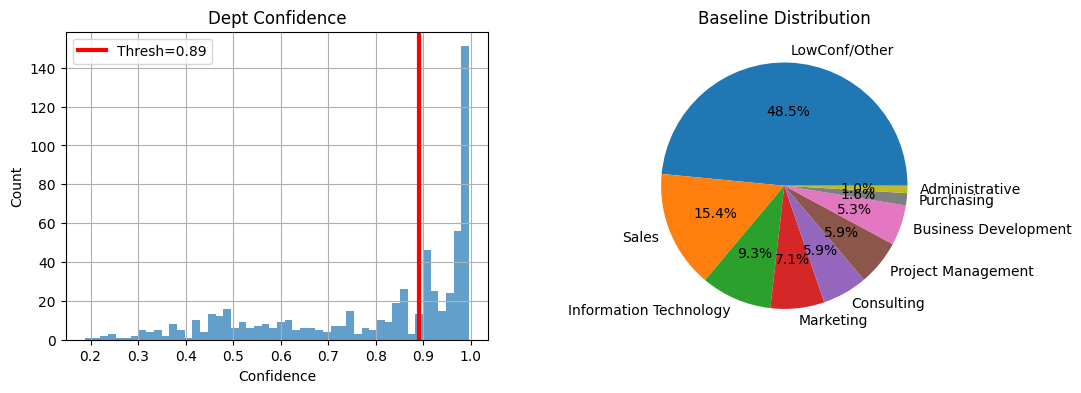

✅ Saved: dept_baseline_only.csv


In [ ]:
from transformers import pipeline
import pandas as pd
import json, numpy as np
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Config
DEPT_MODEL_PATH = "/content/drive/MyDrive/PDS_Snapaddy/models/jobbertv3_department_FULL_weighted"
CSV_PATH = "/content/drive/MyDrive/PDS_Snapaddy/df_validate.csv"
DEPT_THRESH = 0.8  # Tune: 0.3=mehr, 0.7=sicherer

# 1. Load + Predict
df_validate = pd.read_csv(CSV_PATH)
dept_classifier = pipeline("text-classification", model=DEPT_MODEL_PATH, tokenizer=DEPT_MODEL_PATH)

texts = df_validate["text"].fillna("").astype(str).tolist()
dept_preds = dept_classifier(texts, top_k=1)

df_validate["predicted_dept"] = [p[0]['label'] for p in dept_preds]
df_validate["dept_conf"] = [p[0]['score'] for p in dept_preds]

# 2. Decode
with open(f"{DEPT_MODEL_PATH}/label_encoder.json", "r") as f:
    le_info = json.load(f)
id2label = {int(k): v for k, v in le_info["mapping"].items()}
df_validate["predicted_dept_decoded"] = df_validate["predicted_dept"].apply(
    lambda x: id2label.get(int(x.split("_")[1]), x) if x.startswith("LABEL_") else x
)

# 3. Baseline Filter (CONFIDENCE ONLY)
df_validate["final_dept_baseline"] = np.where(
    df_validate["dept_conf"] >= DEPT_THRESH,
    df_validate["predicted_dept_decoded"],
    "LowConf/Other"
)

# 4. Results
print("=== BASELINE (Conf ≥ {:.1f}) ===".format(DEPT_THRESH))
print(df_validate["final_dept_baseline"].value_counts())
print(f"LowConf Reject: {(df_validate['dept_conf'] < DEPT_THRESH).mean():.1%}")

# 5. Eval (confident only)
mask = df_validate["final_dept_baseline"] != "LowConf/Other"
df_eval = df_validate[mask].dropna(subset=["label", "final_dept_baseline"])
acc = accuracy_score(df_eval["label"], df_eval["final_dept_baseline"])
print(f" Baseline Acc: {acc:.3f} ({len(df_eval)} confident Samples)")
print(classification_report(df_eval["label"], df_eval["final_dept_baseline"]))

# 6. Confidence Distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df_validate["dept_conf"], bins=50, alpha=0.7)
plt.axvline(DEPT_THRESH, color='r', lw=3, label=f'Thresh={DEPT_THRESH}')
plt.xlabel("Confidence"); plt.ylabel("Count"); plt.title("Dept Confidence"); plt.legend(); plt.grid()

plt.subplot(1, 2, 2)
dept_dist = df_validate["final_dept_baseline"].value_counts()
plt.pie(dept_dist.values, labels=dept_dist.index, autopct='%1.1f%%')
plt.title("Baseline Distribution")
plt.show()

# 7. Save
df_validate.to_csv("/content/drive/MyDrive/PDS_Snapaddy/dept_baseline_only.csv", index=False)
print("Saved: dept_baseline_only.csv")


########################

threshold + OOD scores

In [ ]:
from transformers import pipeline
import pandas as pd
import json, numpy as np
from sklearn.metrics import accuracy_score, classification_report

DEPT_MODEL_PATH = "/content/drive/MyDrive/PDS_Snapaddy/models/jobbertv3_department_FULL_weighted"
CSV_PATH = "/content/drive/MyDrive/PDS_Snapaddy/df_validate.csv"

# Config (tunebar!)
DEPT_THRESH = 0.8      # Confidence
MAHA_THRESH = 209.5653 # OOD Dist

# 1. Load + Dept Predict ALL
df_validate = pd.read_csv(CSV_PATH)
dept_classifier = pipeline("text-classification", model=DEPT_MODEL_PATH, tokenizer=DEPT_MODEL_PATH)

texts = df_validate["text"].fillna("").astype(str).tolist()
dept_preds = dept_classifier(texts, top_k=1)

df_validate["predicted_dept"] = [p[0]['label'] for p in dept_preds]
df_validate["dept_conf"] = [p[0]['score'] for p in dept_preds]

# 2. Decode
with open(f"{DEPT_MODEL_PATH}/label_encoder.json", "r") as f:
    le_info = json.load(f)
id2label = {int(k): v for k, v in le_info["mapping"].items()}
df_validate["dept_raw"] = df_validate["predicted_dept"].apply(
    lambda x: id2label.get(int(x.split("_")[1]), x) if x.startswith("LABEL_") else x
)

# 3. MAHA + Conf Filter → EINZIGER Other Fallback!
df_validate["maha_known"] = df_validate["ood_score_mahalanobis"] < MAHA_THRESH
df_validate["final_dept_prod"] = np.where(
    df_validate["maha_known"] & (df_validate["dept_conf"] >= DEPT_THRESH),
    df_validate["dept_raw"],           # Sales/IT/...
    "Other"                            # ← UNSICHER/OOD = Other!
)

# 4. Results (GESAMT!)
print("=== PROD LOGIC (MAHA + Conf) ===")
print(df_validate["final_dept_prod"].value_counts())
other_rate = (df_validate["final_dept_prod"] == "Other").mean()
print(f"Other Rate: {other_rate:.1%} ({other_rate*623:.0f} Samples)")

# 5. GESAMT ACC (ALLE Samples!)
gesamt_acc = accuracy_score(df_validate["label"], df_validate["final_dept_prod"])
print(f" **GESAMT ACC: {gesamt_acc:.3f}** (623 Samples!)")

# Detailed Report
print("\nDetailed Classification Report:")
print(classification_report(df_validate["label"], df_validate["final_dept_prod"]))

# 6. Save
df_validate.to_csv("/content/drive/MyDrive/PDS_Snapaddy/dept_prod_final.csv", index=False)
print("Saved: dept_prod_final.csv")


The tokenizer you are loading from '/content/drive/MyDrive/PDS_Snapaddy/models/jobbertv3_department_FULL_weighted' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Device set to use cpu


=== PROD LOGIC (MAHA + Conf) ===
final_dept_prod
Other                     480
Sales                      32
Information Technology     31
Project Management         19
Business Development       18
Consulting                 17
Marketing                  13
Human Resources             8
Purchasing                  5
Name: count, dtype: int64
Other Rate: 77.0% (480 Samples)
✅ **GESAMT ACC: 0.713** (623 Samples!)

Detailed Classification Report:
                        precision    recall  f1-score   support

        Administrative       0.00      0.00      0.00        14
  Business Development       0.33      0.30      0.32        20
            Consulting       0.94      0.41      0.57        39
      Customer Support       0.00      0.00      0.00         6
       Human Resources       0.88      0.44      0.58        16
Information Technology       0.74      0.37      0.49        62
             Marketing       0.69      0.41      0.51        22
                 Other       0.69     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


threshold ood + translate

In [ ]:
from transformers import pipeline
import pandas as pd
import json, numpy as np
from sklearn.metrics import accuracy_score, classification_report
from googletrans import Translator, LANGUAGES  # !pip install googletrans==4.0.0-rc1

DEPT_MODEL_PATH = "/content/drive/MyDrive/PDS_Snapaddy/models/jobbertv3_department_FULL_weighted"
CSV_PATH = "/content/drive/MyDrive/PDS_Snapaddy/df_validate.csv"

DEPT_THRESH = 0.8
MAHA_THRESH = 209.5653

translator = Translator()

def safe_translate(text, max_retries=3):
    """Robust batch-safe translate"""
    if pd.isna(text) or not str(text).strip():
        return ""
    for _ in range(max_retries):
        try:
            result = translator.translate(str(text).strip(), dest='en')
            return result.text
        except Exception as e:
            continue
    return str(text)  # Fallback original

# 1. Load + BATCH Translate (schneller!)
df_validate = pd.read_csv(CSV_PATH)
print("Batch Translate to EN (~1-2min)...")
df_validate["text_en"] = df_validate["text"].fillna("").apply(safe_translate)

# 2. Dept Predict auf EN
dept_classifier = pipeline("text-classification", model=DEPT_MODEL_PATH, tokenizer=DEPT_MODEL_PATH)
texts_en = df_validate["text_en"].fillna("").tolist()
dept_preds = dept_classifier(texts_en, top_k=1)

df_validate["predicted_dept"] = [p[0]['label'] for p in dept_preds]
df_validate["dept_conf"] = [p[0]['score'] for p in dept_preds]

# 3. Decode + MAHA Filter
with open(f"{DEPT_MODEL_PATH}/label_encoder.json", "r") as f:
    le_info = json.load(f)
id2label = {int(k): v for k, v in le_info["mapping"].items()}
df_validate["dept_raw"] = df_validate["predicted_dept"].apply(
    lambda x: id2label.get(int(x.split("_")[1]), x) if x.startswith("LABEL_") else x
)

df_validate["maha_known"] = df_validate["ood_score_mahalanobis"] < MAHA_THRESH
df_validate["final_dept_prod"] = np.where(
    df_validate["maha_known"] & (df_validate["dept_conf"] >= DEPT_THRESH),
    df_validate["dept_raw"],
    "Other"
)

# 4. Results
print("=== EN + MAHA + Conf ===")
print(df_validate["final_dept_prod"].value_counts())
print(f"Gesamt Acc: {accuracy_score(df_validate['label'], df_validate['final_dept_prod']):.3f}")
print(classification_report(df_validate["label"], df_validate["final_dept_prod"]))

df_validate.to_csv("/content/drive/MyDrive/PDS_Snapaddy/dept_en_prod_final.csv", index=False)


🔄 Batch Translate to EN (~1-2min)...


/tmp/ipython-input-237965424.py:21: RuntimeWarning: coroutine 'Translator.translate' was never awaited
  result = translator.translate(str(text).strip(), dest='en')
/usr/local/lib/python3.12/dist-packages/pandas/core/algorithms.py:1743: RuntimeWarning: coroutine 'Translator.translate' was never awaited
  return lib.map_infer(values, mapper, convert=convert)
The tokenizer you are loading from '/content/drive/MyDrive/PDS_Snapaddy/models/jobbertv3_department_FULL_weighted' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Device set to use cpu


=== EN + MAHA + Conf ===
final_dept_prod
Other                     480
Sales                      32
Information Technology     31
Project Management         19
Business Development       18
Consulting                 17
Marketing                  13
Human Resources             8
Purchasing                  5
Name: count, dtype: int64
Gesamt Acc: 0.713
                        precision    recall  f1-score   support

        Administrative       0.00      0.00      0.00        14
  Business Development       0.33      0.30      0.32        20
            Consulting       0.94      0.41      0.57        39
      Customer Support       0.00      0.00      0.00         6
       Human Resources       0.88      0.44      0.58        16
Information Technology       0.74      0.37      0.49        62
             Marketing       0.69      0.41      0.51        22
                 Other       0.69      0.96      0.80       344
    Project Management       1.00      0.49      0.66        39
    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
